# Multistage Comparison

This notebook summarizes the multistage correction experiment for thesis-ready reporting. It uses the posthoc checkpoint evaluation as the primary source for external ID/OOD metrics, while preserving the stage summaries and residual probes for follow-up analysis.

Pipeline script: `src/experiments/pipeline/run_multistage_comparison.py`  
Raw outputs: `outputs/multistage_comparison/`  
Table exports: `results/tables/05_multistage/`

## Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import sys


def _find_repo_root(start: Path | None = None) -> Path:
    start = (Path.cwd() if start is None else start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            return candidate
    raise FileNotFoundError(f"Could not find repository root from {start}")

REPO = _find_repo_root()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.visualization.results_helpers import (
    aggregate_mean_sem,
    epoch_metrics_path,
    ensure_repo_root_on_path,
    load_json,
    load_posthoc_external_eval,
    mean_sem_text,
    overlay_posthoc_external_eval,
    read_epoch_metrics,
)
from results.notebook_utils import table_dir, write_table, write_numeric_table

from src.visualization.thesis_style import (
    DTU_COLORS,
    NEUTRAL_COLORS,
    apply_thesis_axis_style,
    log_minor_grid,
    save_figure,
    set_thesis_style,
)

REPO = ensure_repo_root_on_path(REPO)
ROOT = REPO / "outputs" / "multistage_comparison"
EXPORT = REPO / "results" / "data" / "thesis_05_multistage"
# Scratch export directory is intentionally not created for repository submission.
TABLE_EXPORT = table_dir("multistage")

set_thesis_style()

STRATEGY_ORDER = [
    "multistage_adam_correction",
    "multistage_adam_lbfgs_correction",
    "multistage_adam_ssbroyden_correction",
]
EXPECTED_SEEDS = ["s01", "s02", "s03"]

STRATEGY_LABEL = {
    "multistage_adam_correction": "Adam correction",
    "multistage_adam_lbfgs_correction": "Adam + L-BFGS correction",
    "multistage_adam_ssbroyden_correction": "Adam + SSBroyden correction",
}
STRATEGY_COLORS = {
    "multistage_adam_correction": NEUTRAL_COLORS["muted"],
    "multistage_adam_lbfgs_correction": DTU_COLORS["green"],
    "multistage_adam_ssbroyden_correction": DTU_COLORS["corporate_red"],
}

DESIGN_ROWS = [
    {
        "strategy": "multistage_adam_correction",
        "label": "Adam correction",
        "stages": 2,
        "epochs": "1000 Adam + 500 L-BFGS; 3500 Adam",
        "optimizer sequence": "Adam/L-BFGS warmup -> Adam residual",
        "terminal correction": "Adam",
    },
    {
        "strategy": "multistage_adam_lbfgs_correction",
        "label": "Adam + L-BFGS correction",
        "stages": 3,
        "epochs": "1000 Adam + 500 L-BFGS; 2000 Adam; 1500 L-BFGS",
        "optimizer sequence": "Adam/L-BFGS warmup -> Adam residual -> L-BFGS residual",
        "terminal correction": "L-BFGS",
    },
    {
        "strategy": "multistage_adam_ssbroyden_correction",
        "label": "Adam + SSBroyden correction",
        "stages": 3,
        "epochs": "1000 Adam + 500 L-BFGS; 2000 Adam; 1500 SSBroyden",
        "optimizer sequence": "Adam/L-BFGS warmup -> Adam residual -> SSBroyden residual",
        "terminal correction": "SSBroyden",
    },
]


def strategy_label(strategy: str) -> str:
    return STRATEGY_LABEL.get(str(strategy), str(strategy))


def ordered(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if "strategy" in out.columns:
        out["strategy"] = pd.Categorical(out["strategy"].astype(str), categories=STRATEGY_ORDER, ordered=True)
    sort_cols = [col for col in ["strategy", "seed_label"] if col in out.columns]
    return out.sort_values(sort_cols).reset_index(drop=True)


def export_fig(fig, name: str):
    # Figure export disabled for repository submission; keep plot inline.
    paths = []
    # paths = save_figure(fig, EXPORT / name, formats=("pdf", "svg", "png"))
    plt.show()
    return paths


## Experiment Design

The available multistage batch corresponds to the fixed 5000-epoch correction-stage design. It is not the older proportional stage-count sweep documented historically.

In [2]:
design_table = pd.DataFrame(DESIGN_ROWS)
write_table(design_table, "multistage", name="design")
display(design_table[["label", "stages", "epochs", "optimizer sequence", "terminal correction"]])


,label,stages,epochs,optimizer sequence,terminal correction
0,Adam correction,2,1000 Adam + 500 L-BFGS; 3500 Adam,Adam/L-BFGS warmup -> Adam residual,Adam
1,Adam + L-BFGS correction,3,1000 Adam + 500 L-BFGS; 2000 Adam; 1500 L-BFGS,Adam/L-BFGS warmup -> Adam residual -> L-BFGS ...,L-BFGS
2,Adam + SSBroyden correction,3,1000 Adam + 500 L-BFGS; 2000 Adam; 1500 SSBroyden,Adam/L-BFGS warmup -> Adam residual -> SSBroyd...,SSBroyden


## Data Loading

Timestamped batch folders are combined into one run table. The posthoc checkpoint evaluation is overlaid before aggregation so the thesis metrics use the exclusive external OOD definition.

In [3]:
summary_frames = []
manifest_rows = []
stage_rows = []
probe_rows = []
epoch_completeness_rows = []

for batch_dir in sorted(ROOT.glob("*")):
    if not batch_dir.is_dir():
        continue
    manifest = load_json(batch_dir / "run_manifest.json", default={}) or {}
    artifacts = manifest.get("artifacts", {})
    manifest_runs = manifest.get("runs", [])
    summary_path = batch_dir / "summary.csv"
    manifest_rows.append({
        "batch": batch_dir.name,
        "summary_present": summary_path.exists(),
        "manifest_runs": len(manifest_runs),
        "manifest_completed": sum(1 for run in manifest_runs if run.get("status") == "completed"),
        "strategies": artifacts.get("strategies"),
        "seed_labels": artifacts.get("seed_labels"),
        "total_epochs": artifacts.get("total_epochs"),
        "dataset_reference_id": artifacts.get("dataset_reference_id"),
        "id_eval_id": artifacts.get("id_eval_id"),
        "ood_eval_id": artifacts.get("ood_eval_id"),
    })
    if not summary_path.exists():
        continue

    summary = pd.read_csv(summary_path)
    summary["batch"] = batch_dir.name
    summary_frames.append(summary)

    for _, row in summary.iterrows():
        run_dir = batch_dir / "runs" / str(row["run_name"])
        stage_summary = load_json(run_dir / "stage_summary.json", default=[]) or []
        for entry in stage_summary:
            rec = {
                "batch": batch_dir.name,
                "run_name": row["run_name"],
                "strategy": row["strategy"],
                "seed_label": row["seed_label"],
                **{k: v for k, v in entry.items() if k != "final_train_component_losses"},
            }
            for component, value in (entry.get("final_train_component_losses") or {}).items():
                rec[f"final_train_{component}_loss"] = value
            stage_rows.append(rec)

        residual_probe = load_json(run_dir / "stage_residual_probe.json", default=[]) or []
        for entry in residual_probe:
            probe_rows.append({
                "batch": batch_dir.name,
                "run_name": row["run_name"],
                "strategy": row["strategy"],
                "seed_label": row["seed_label"],
                **entry,
            })

        epoch_path = epoch_metrics_path(ROOT, batch_dir.name, row["run_name"])
        epoch_frame = read_epoch_metrics(epoch_path, columns=["global_epoch"])
        max_epoch = pd.to_numeric(epoch_frame.get("global_epoch"), errors="coerce").max() if not epoch_frame.empty else np.nan
        final_epoch = pd.to_numeric(pd.Series([row.get("global_epoch")]), errors="coerce").iloc[0]
        epoch_completeness_rows.append({
            "batch": batch_dir.name,
            "run_name": row["run_name"],
            "strategy": row["strategy"],
            "seed_label": row["seed_label"],
            "summary_final_epoch": final_epoch,
            "epoch_csv_rows": len(epoch_frame),
            "epoch_csv_max_epoch": max_epoch,
            "epoch_csv_complete_for_final_epoch": bool(pd.notna(max_epoch) and pd.notna(final_epoch) and max_epoch >= final_epoch),
        })

if not summary_frames:
    raise FileNotFoundError(f"No summary.csv files found under {ROOT}")

runs = pd.concat(summary_frames, ignore_index=True, sort=False)
posthoc_eval = load_posthoc_external_eval(ROOT, setting="best_train_exclusive_ood")
if posthoc_eval.empty:
    raise FileNotFoundError(f"No posthoc evaluation results found under {ROOT}")

runs = overlay_posthoc_external_eval(runs, posthoc_eval)
runs["has_posthoc_eval"] = runs.get("posthoc_status", pd.Series(index=runs.index, dtype=object)).eq("completed")
runs["has_complete_external_eval"] = runs[["best_id_eval_mse", "best_ood_eval_mse"]].notna().all(axis=1)
runs = ordered(runs)

manifests = pd.DataFrame(manifest_rows).sort_values("batch").reset_index(drop=True)
stages = ordered(pd.DataFrame(stage_rows)) if stage_rows else pd.DataFrame()
probes = ordered(pd.DataFrame(probe_rows)) if probe_rows else pd.DataFrame()
epoch_completeness = ordered(pd.DataFrame(epoch_completeness_rows)) if epoch_completeness_rows else pd.DataFrame()

# Scratch export disabled for repository submission; keep derived data in memory.
# manifests.to_csv(EXPORT / "batches.csv", index=False)
# runs.to_csv(EXPORT / "runs.csv", index=False)
# stages.to_csv(EXPORT / "stage_summaries.csv", index=False)
# probes.to_csv(EXPORT / "stage_residual_probes.csv", index=False)
# epoch_completeness.to_csv(EXPORT / "epoch_completeness.csv", index=False)

print(f"Loaded {len(runs)} runs from {len(manifests)} batches.")
print(f"Posthoc completed: {int(runs['has_posthoc_eval'].sum())}/{len(runs)}")
display(manifests)
display(runs[["batch", "run_name", "strategy", "seed_label", "status", "completed_num_stages", "has_posthoc_eval", "has_complete_external_eval"]])


Loaded 9 runs from 1 batches.
Posthoc completed: 9/9


/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_19265/1185393521.py:82: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  runs["has_posthoc_eval"] = runs.get("posthoc_status", pd.Series(index=runs.index, dtype=object)).eq("completed")
/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_19265/1185393521.py:83: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  runs["has_complete_external_eval"] = runs[["best_id_eval_mse", "best_ood_eval_mse"]].notna().all(axis=1)


,batch,summary_present,manifest_runs,manifest_completed,strategies,seed_labels,total_epochs,dataset_reference_id,id_eval_id,ood_eval_id
0,20260517_131245,True,9,9,"[multistage_adam_correction, multistage_adam_l...","[s01, s02, s03]",30000,main_SM4_qbc_b512_ds01,id_SM4_lhs_b512_ds01,ood_SM4_wide_ic_b512_ds01


,batch,run_name,strategy,seed_label,status,completed_num_stages,has_posthoc_eval,has_complete_external_eval
0,20260517_131245,multistage_adam_correction_s01,multistage_adam_correction,s01,completed,2,True,True
1,20260517_131245,multistage_adam_correction_s02,multistage_adam_correction,s02,completed,2,True,True
2,20260517_131245,multistage_adam_correction_s03,multistage_adam_correction,s03,completed,2,True,True
3,20260517_131245,multistage_adam_lbfgs_correction_s01,multistage_adam_lbfgs_correction,s01,completed,3,True,True
4,20260517_131245,multistage_adam_lbfgs_correction_s02,multistage_adam_lbfgs_correction,s02,completed,3,True,True
5,20260517_131245,multistage_adam_lbfgs_correction_s03,multistage_adam_lbfgs_correction,s03,completed,3,True,True
6,20260517_131245,multistage_adam_ssbroyden_correction_s01,multistage_adam_ssbroyden_correction,s01,completed,3,True,True
7,20260517_131245,multistage_adam_ssbroyden_correction_s02,multistage_adam_ssbroyden_correction,s02,completed,3,True,True
8,20260517_131245,multistage_adam_ssbroyden_correction_s03,multistage_adam_ssbroyden_correction,s03,completed,3,True,True


## Completeness

In [4]:
completion_rows = []
for strategy in STRATEGY_ORDER:
    subset = runs[runs["strategy"].astype(str) == strategy]
    stage_subset = stages[stages["strategy"].astype(str) == strategy] if not stages.empty else pd.DataFrame()
    probe_subset = probes[probes["strategy"].astype(str) == strategy] if not probes.empty else pd.DataFrame()
    epoch_subset = epoch_completeness[epoch_completeness["strategy"].astype(str) == strategy] if not epoch_completeness.empty else pd.DataFrame()
    present = sorted(subset["seed_label"].dropna().astype(str).unique())
    posthoc_complete = sorted(subset.loc[subset["has_posthoc_eval"], "seed_label"].dropna().astype(str).unique())
    missing = [seed for seed in EXPECTED_SEEDS if seed not in present]
    notes = []
    if missing:
        notes.append("missing expected seeds")
    if not bool(subset["status"].eq("completed").all()):
        notes.append("incomplete runs")
    if not bool(subset["has_complete_external_eval"].all()):
        notes.append("external eval incomplete")
    if not epoch_subset.empty and not bool(epoch_subset["epoch_csv_complete_for_final_epoch"].all()):
        notes.append("epoch metrics incomplete")
    completion_rows.append({
        "Strategy": strategy_label(strategy),
        "Seeds present": ", ".join(present) if present else "n/a",
        "Posthoc seeds": ", ".join(posthoc_complete) if posthoc_complete else "n/a",
        "Missing expected seeds": ", ".join(missing) if missing else "none",
        "n runs": len(subset),
        "n completed": int(subset["status"].eq("completed").sum()),
        "n posthoc": int(subset["has_posthoc_eval"].sum()),
        "stage summary entries": len(stage_subset),
        "residual probe entries": len(probe_subset),
        "epoch complete runs": int(epoch_subset["epoch_csv_complete_for_final_epoch"].sum()) if not epoch_subset.empty else 0,
        "notes": "; ".join(notes),
    })
completion = pd.DataFrame(completion_rows)
# Scratch export disabled for repository submission; keep derived data in memory.
# completion.to_csv(EXPORT / "completion.csv", index=False)
display(completion)


,Strategy,Seeds present,Posthoc seeds,Missing expected seeds,n runs,n completed,n posthoc,stage summary entries,residual probe entries,epoch complete runs,notes
0,Adam correction,"s01, s02, s03","s01, s02, s03",none,3,3,3,6,3,3,
1,Adam + L-BFGS correction,"s01, s02, s03","s01, s02, s03",none,3,3,3,9,6,3,
2,Adam + SSBroyden correction,"s01, s02, s03","s01, s02, s03",none,3,3,3,9,6,3,


## Thesis Summary Table

Mean values and SEM are computed across the three model seeds for each multistage strategy. ID/OOD metrics come from the posthoc checkpoint evaluation with exclusive OOD filtering.

In [5]:
POSTHOC_SUMMARY_METRICS = [
    "best_id_eval_mse", "best_id_eval_rmse", "best_id_eval_mae", "best_id_eval_max_abs_error",
    "best_id_eval_trajectory_mse_mean", "best_id_eval_trajectory_mse_p90",
    "best_id_eval_trajectory_mse_p95", "best_id_eval_trajectory_mse_max",
    "best_id_eval_trajectory_rmse_mean", "best_id_eval_trajectory_rmse_p90",
    "best_id_eval_trajectory_rmse_p95", "best_id_eval_trajectory_rmse_max",
    "best_id_eval_trajectory_max_abs_error_mean",
    "best_id_eval_trajectory_max_abs_error_p95",
    "best_id_eval_trajectory_max_abs_error_max",
    "best_id_eval_n_rows", "best_id_eval_n_trajectories",
    "best_ood_eval_mse", "best_ood_eval_rmse", "best_ood_eval_mae", "best_ood_eval_max_abs_error",
    "best_ood_eval_trajectory_mse_mean", "best_ood_eval_trajectory_mse_p90",
    "best_ood_eval_trajectory_mse_p95", "best_ood_eval_trajectory_mse_max",
    "best_ood_eval_trajectory_rmse_mean", "best_ood_eval_trajectory_rmse_p90",
    "best_ood_eval_trajectory_rmse_p95", "best_ood_eval_trajectory_rmse_max",
    "best_ood_eval_trajectory_max_abs_error_mean",
    "best_ood_eval_trajectory_max_abs_error_p95",
    "best_ood_eval_trajectory_max_abs_error_max",
    "best_ood_eval_n_rows_before_filter", "best_ood_eval_n_trajectories_before_filter",
    "best_ood_eval_n_rows", "best_ood_eval_n_trajectories",
]
POSTHOC_METRIC_LABELS = [
    ("best_id_eval_mse", "ID MSE"),
    ("best_id_eval_rmse", "ID RMSE"),
    ("best_id_eval_mae", "ID MAE"),
    ("best_id_eval_max_abs_error", "ID max abs error"),
    ("best_id_eval_trajectory_mse_mean", "ID trajectory MSE mean"),
    ("best_id_eval_trajectory_mse_p90", "ID trajectory MSE p90"),
    ("best_id_eval_trajectory_mse_p95", "ID trajectory MSE p95"),
    ("best_id_eval_trajectory_mse_max", "ID trajectory MSE max"),
    ("best_id_eval_trajectory_rmse_mean", "ID trajectory RMSE mean"),
    ("best_id_eval_trajectory_rmse_p90", "ID trajectory RMSE p90"),
    ("best_id_eval_trajectory_rmse_p95", "ID trajectory RMSE p95"),
    ("best_id_eval_trajectory_rmse_max", "ID trajectory RMSE max"),
    ("best_id_eval_trajectory_max_abs_error_mean", "ID trajectory max abs error mean"),
    ("best_id_eval_trajectory_max_abs_error_p95", "ID trajectory max abs error p95"),
    ("best_id_eval_trajectory_max_abs_error_max", "ID trajectory max abs error max"),
    ("best_id_eval_n_rows", "ID rows"),
    ("best_id_eval_n_trajectories", "ID trajectories"),
    ("best_ood_eval_mse", "OOD MSE"),
    ("best_ood_eval_rmse", "OOD RMSE"),
    ("best_ood_eval_mae", "OOD MAE"),
    ("best_ood_eval_max_abs_error", "OOD max abs error"),
    ("best_ood_eval_trajectory_mse_mean", "OOD trajectory MSE mean"),
    ("best_ood_eval_trajectory_mse_p90", "OOD trajectory MSE p90"),
    ("best_ood_eval_trajectory_mse_p95", "OOD trajectory MSE p95"),
    ("best_ood_eval_trajectory_mse_max", "OOD trajectory MSE max"),
    ("best_ood_eval_trajectory_rmse_mean", "OOD trajectory RMSE mean"),
    ("best_ood_eval_trajectory_rmse_p90", "OOD trajectory RMSE p90"),
    ("best_ood_eval_trajectory_rmse_p95", "OOD trajectory RMSE p95"),
    ("best_ood_eval_trajectory_rmse_max", "OOD trajectory RMSE max"),
    ("best_ood_eval_trajectory_max_abs_error_mean", "OOD trajectory max abs error mean"),
    ("best_ood_eval_trajectory_max_abs_error_p95", "OOD trajectory max abs error p95"),
    ("best_ood_eval_trajectory_max_abs_error_max", "OOD trajectory max abs error max"),
    ("best_ood_eval_n_rows_before_filter", "OOD rows before filter"),
    ("best_ood_eval_n_trajectories_before_filter", "OOD trajectories before filter"),
    ("best_ood_eval_n_rows", "OOD rows"),
    ("best_ood_eval_n_trajectories", "OOD trajectories"),
]
COUNT_METRICS = {
    "best_id_eval_n_rows", "best_id_eval_n_trajectories",
    "best_ood_eval_n_rows_before_filter", "best_ood_eval_n_trajectories_before_filter",
    "best_ood_eval_n_rows", "best_ood_eval_n_trajectories",
}
SUMMARY_METRICS = POSTHOC_SUMMARY_METRICS + [
    "final_test_mse",
    "best_checkpoint_epoch",
    "completed_num_stages",
    "training_seconds",
    "total_seconds",
]

thesis_numeric = aggregate_mean_sem(
    runs,
    group_cols="strategy",
    metrics=SUMMARY_METRICS,
    seed_col="seed_label",
    run_col="run_name",
    order_col="strategy",
    order=STRATEGY_ORDER,
)
write_numeric_table(thesis_numeric, "multistage")


def metric_text(row: pd.Series, metric: str, *, decimals: int = 2, scientific: bool = True) -> str:
    if pd.isna(row.get(f"{metric}_mean")) and pd.isna(row.get(f"{metric}_sem")):
        return "n/a"
    return mean_sem_text(row, metric, decimals=decimals, scientific=scientific)

rows = []
for _, row in thesis_numeric.iterrows():
    record = {
        "Strategy": strategy_label(row["strategy"]),
        "Seeds": row.get("seeds", ""),
    }
    for metric, label in POSTHOC_METRIC_LABELS:
        if metric in COUNT_METRICS:
            record[label] = metric_text(row, metric, decimals=0, scientific=False)
        else:
            record[label] = metric_text(row, metric, decimals=2, scientific=True)
    record["test MSE"] = metric_text(row, "final_test_mse", decimals=2, scientific=True)
    record["best checkpoint epoch"] = metric_text(row, "best_checkpoint_epoch", decimals=0, scientific=False)
    record["completed stages"] = metric_text(row, "completed_num_stages", decimals=0, scientific=False)
    record["training time [s]"] = metric_text(row, "training_seconds", decimals=1, scientific=False)
    record["total time [s]"] = metric_text(row, "total_seconds", decimals=1, scientific=False)
    rows.append(record)

thesis_table = pd.DataFrame(rows)
write_table(thesis_table, "multistage")
display(thesis_table)


,Strategy,Seeds,ID MSE,ID RMSE,ID MAE,ID max abs error,ID trajectory MSE mean,ID trajectory MSE p90,ID trajectory MSE p95,ID trajectory MSE max,...,OOD trajectory max abs error max,OOD rows before filter,OOD trajectories before filter,OOD rows,OOD trajectories,test MSE,best checkpoint epoch,completed stages,training time [s],total time [s]
0,Adam correction,"s01,s02,s03",3.20e-06 +/- 4.08e-07,1.78e-03 +/- 1.15e-04,1.12e-03 +/- 6.87e-05,2.49e-02 +/- 1.23e-03,3.20e-06 +/- 4.08e-07,6.43e-06 +/- 8.81e-07,8.89e-06 +/- 8.19e-07,2.85e-05 +/- 5.78e-06,...,1.27e+00 +/- 5.84e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.35e-06 +/- 3.68e-07,1360 +/- 170,2 +/- 0,9738.6 +/- 55.2,9746.4 +/- 58.1
1,Adam + L-BFGS correction,"s01,s02,s03",3.20e-06 +/- 4.08e-07,1.78e-03 +/- 1.15e-04,1.12e-03 +/- 6.87e-05,2.49e-02 +/- 1.23e-03,3.20e-06 +/- 4.08e-07,6.43e-06 +/- 8.81e-07,8.89e-06 +/- 8.19e-07,2.85e-05 +/- 5.78e-06,...,1.27e+00 +/- 5.84e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.27e-06 +/- 3.80e-07,1360 +/- 170,3 +/- 0,14693.4 +/- 10.6,14699.3 +/- 11.6
2,Adam + SSBroyden correction,"s01,s02,s03",3.20e-06 +/- 4.08e-07,1.78e-03 +/- 1.15e-04,1.12e-03 +/- 6.87e-05,2.49e-02 +/- 1.23e-03,3.20e-06 +/- 4.08e-07,6.43e-06 +/- 8.81e-07,8.89e-06 +/- 8.19e-07,2.85e-05 +/- 5.78e-06,...,1.27e+00 +/- 5.84e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.25e-06 +/- 3.44e-07,1360 +/- 170,3 +/- 0,7331.4 +/- 72.8,7336.9 +/- 72.7


## Stage-Wise Convergence

The convergence view compares the shared warmup and later correction phases. Curves are seed-averaged and smoothed with a 100-epoch rolling median for visualization only; the raw epoch metrics remain unchanged.

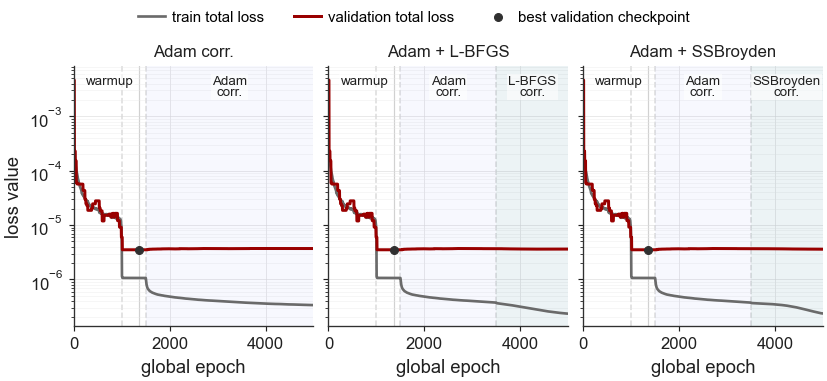

/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/Chapters/6_Results/MS_convergence.png


In [6]:
CONVERGENCE_SMOOTH_WINDOW = 100
CONVERGENCE_COLUMNS = ["global_epoch", "train_total_loss", "val_total_loss"]

STAGE_BOUNDARIES = {
    "multistage_adam_correction": [1000, 1500],
    "multistage_adam_lbfgs_correction": [1000, 1500, 3500],
    "multistage_adam_ssbroyden_correction": [1000, 1500, 3500],
}
STAGE_LABELS = {
    "multistage_adam_correction": [
        (750, "warmup"),
        (3250, "Adam\ncorr."),
    ],
    "multistage_adam_lbfgs_correction": [
        (750, "warmup"),
        (2500, "Adam\ncorr."),
        (4250, "L-BFGS\ncorr."),
    ],
    "multistage_adam_ssbroyden_correction": [
        (750, "warmup"),
        (2500, "Adam\ncorr."),
        (4250, "SSBroyden\ncorr."),
    ],
}

convergence_parts = []
for _, run in runs.iterrows():
    epoch_path = epoch_metrics_path(ROOT, run["batch"], run["run_name"])
    epoch_frame = read_epoch_metrics(epoch_path, columns=CONVERGENCE_COLUMNS)
    if epoch_frame.empty:
        continue
    epoch_frame = epoch_frame.dropna(subset=["global_epoch"]).copy()
    epoch_frame["global_epoch"] = epoch_frame["global_epoch"].astype(int)
    epoch_frame["strategy"] = str(run["strategy"])
    epoch_frame["seed_label"] = str(run["seed_label"])
    epoch_frame["run_name"] = str(run["run_name"])
    convergence_parts.append(epoch_frame)

if not convergence_parts:
    raise FileNotFoundError("No epoch_metrics.csv files found for multistage convergence plot.")

convergence_raw = pd.concat(convergence_parts, ignore_index=True, sort=False)
# Scratch export disabled for repository submission; keep derived data in memory.
# convergence_raw.to_csv(EXPORT / "stagewise_convergence_raw.csv", index=False)

convergence_mean = (
    convergence_raw
    .groupby(["strategy", "global_epoch"], observed=True)[["train_total_loss", "val_total_loss"]]
    .mean()
    .reset_index()
)

smoothed_parts = []
for strategy, sub in convergence_mean.groupby("strategy", observed=True):
    sub = sub.sort_values("global_epoch").copy()
    for metric in ["train_total_loss", "val_total_loss"]:
        sub[f"{metric}_smooth"] = (
            sub[metric]
            .rolling(CONVERGENCE_SMOOTH_WINDOW, center=True, min_periods=1)
            .median()
        )
    smoothed_parts.append(sub)
convergence_smooth = pd.concat(smoothed_parts, ignore_index=True, sort=False)
# Scratch export disabled for repository submission; keep derived data in memory.
# convergence_smooth.to_csv(EXPORT / "stagewise_convergence_smoothed.csv", index=False)

best_epoch_by_strategy = (
    runs.groupby("strategy", observed=True)["best_checkpoint_epoch"]
    .agg(best_epoch_mean="mean", best_epoch_min="min", best_epoch_max="max")
    .reset_index()
)
# Scratch export disabled for repository submission; keep derived data in memory.
# best_epoch_by_strategy.to_csv(EXPORT / "stagewise_convergence_best_epochs.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(6.9, 2.85), sharex=True, sharey=True, constrained_layout=True)
train_color = NEUTRAL_COLORS["muted"]
val_color = DTU_COLORS["corporate_red"]
boundary_color = NEUTRAL_COLORS["grid"]
axis_label_size = 11
tick_label_size = 10
panel_title_size = 10
stage_label_size = 8
legend_font_size = 9

plot_values = convergence_smooth[["train_total_loss_smooth", "val_total_loss_smooth"]].to_numpy().ravel()
plot_values = plot_values[np.isfinite(plot_values) & (plot_values > 0)]
ymin = max(plot_values.min() * 0.6, 1e-8)
ymax = plot_values.max() * 1.8

for ax, strategy in zip(axes, STRATEGY_ORDER):
    sub = convergence_smooth[convergence_smooth["strategy"].astype(str) == strategy]
    if sub.empty:
        ax.set_visible(False)
        continue

    ax.axvspan(1500, 5000, color=DTU_COLORS["blue"], alpha=0.035, linewidth=0)
    if strategy != "multistage_adam_correction":
        ax.axvspan(3500, 5000, color=DTU_COLORS["green"], alpha=0.045, linewidth=0)

    ax.plot(
        sub["global_epoch"],
        sub["train_total_loss_smooth"],
        color=train_color,
        linewidth=1.6,
        label="train total loss",
    )
    ax.plot(
        sub["global_epoch"],
        sub["val_total_loss_smooth"],
        color=val_color,
        linewidth=1.8,
        label="validation total loss",
    )

    for boundary in STAGE_BOUNDARIES[strategy]:
        ax.axvline(boundary, color=boundary_color, linestyle="--", linewidth=0.9, zorder=0)

    best_row = best_epoch_by_strategy[best_epoch_by_strategy["strategy"].astype(str) == strategy]
    if not best_row.empty:
        best_epoch = float(best_row.iloc[0]["best_epoch_mean"])
        nearest_idx = (sub["global_epoch"] - best_epoch).abs().idxmin()
        best_y = sub.loc[nearest_idx, "val_total_loss_smooth"]
        ax.axvline(best_epoch, color=NEUTRAL_COLORS["axis"], linewidth=0.7, alpha=0.22, zorder=0)
        ax.scatter(
            [best_epoch],
            [best_y],
            color=NEUTRAL_COLORS["axis"],
            marker="o",
            s=22,
            zorder=5,
            label="best validation checkpoint",
        )

    plot_title = {
        "multistage_adam_correction": "Adam corr.",
        "multistage_adam_lbfgs_correction": "Adam + L-BFGS",
        "multistage_adam_ssbroyden_correction": "Adam + SSBroyden",
    }[strategy]
    ax.set_title(plot_title, fontsize=panel_title_size)
    ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)
    ax.set_xlim(0, 5000)
    ax.set_xlabel("global epoch", fontsize=axis_label_size)
    log_minor_grid(ax, axis="y")
    apply_thesis_axis_style(ax)
    ax.tick_params(axis="both", labelsize=tick_label_size)

    for x, label in STAGE_LABELS[strategy]:
        ax.text(
            x,
            0.965,
            label,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=stage_label_size,
            linespacing=0.95,
            color=NEUTRAL_COLORS["text"],
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.58, "pad": 0.8},
        )

axes[0].set_ylabel("loss value", fontsize=axis_label_size)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.12), frameon=False, fontsize=legend_font_size)

chapter_export = REPO / "Chapters" / "6_Results" / "MS_convergence.png"
chapter_export.parent.mkdir(parents=True, exist_ok=True)
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(chapter_export, dpi=300, bbox_inches="tight")
plt.show()
print(chapter_export)


## Final Validation Loss Decomposition

The table below reports final-epoch validation loss component magnitudes for the three multistage strategies, aggregated across seeds.

In [7]:
VAL_LOSS_COLUMNS = [
    "val_total_loss",
    "val_data_loss",
    "val_ic_loss",
    "val_dt_loss",
    "val_physics_loss",
]
VAL_LOSS_LABELS = [
    ("val_total_loss", "validation total loss"),
    ("val_data_loss", "validation data loss"),
    ("val_ic_loss", "validation IC loss"),
    ("val_dt_loss", "validation dt loss"),
    ("val_physics_loss", "validation physics loss"),
]

val_loss_rows = []
for _, run in runs.iterrows():
    path = epoch_metrics_path(ROOT, run["batch"], run["run_name"])
    epoch_frame = read_epoch_metrics(path, columns=["global_epoch", *VAL_LOSS_COLUMNS])
    if epoch_frame.empty or "global_epoch" not in epoch_frame.columns:
        continue
    epoch_frame = epoch_frame.dropna(subset=["global_epoch"]).copy()
    if epoch_frame.empty:
        continue
    final_epoch = int(pd.to_numeric(epoch_frame["global_epoch"], errors="coerce").max())
    final_rows = epoch_frame[pd.to_numeric(epoch_frame["global_epoch"], errors="coerce") == final_epoch]
    if final_rows.empty:
        continue
    final = final_rows.iloc[-1]
    val_loss_rows.append({
        "batch": run["batch"],
        "run_name": run["run_name"],
        "strategy": run["strategy"],
        "seed_label": run["seed_label"],
        "final_epoch": final_epoch,
        **{metric: final.get(metric, np.nan) for metric in VAL_LOSS_COLUMNS},
    })

final_val_losses = ordered(pd.DataFrame(val_loss_rows)) if val_loss_rows else pd.DataFrame()
if final_val_losses.empty:
    raise FileNotFoundError("No final validation loss rows could be read from epoch_metrics.csv files.")
# Scratch export disabled for repository submission; keep derived data in memory.
# final_val_losses.to_csv(EXPORT / "final_validation_losses_run_level.csv", index=False)

final_val_loss_numeric = aggregate_mean_sem(
    final_val_losses,
    group_cols="strategy",
    metrics=["final_epoch", *VAL_LOSS_COLUMNS],
    seed_col="seed_label",
    run_col="run_name",
    order_col="strategy",
    order=STRATEGY_ORDER,
)
# Scratch export disabled for repository submission; keep derived data in memory.
# final_val_loss_numeric.to_csv(EXPORT / "final_validation_losses_table_numeric.csv", index=False)

rows = []
for _, row in final_val_loss_numeric.iterrows():
    record = {
        "Strategy": strategy_label(row["strategy"]),
        "Seeds": row.get("seeds", ""),
        "final epoch": mean_sem_text(row, "final_epoch", decimals=0, scientific=False),
    }
    for metric, label in VAL_LOSS_LABELS:
        record[label] = mean_sem_text(row, metric, decimals=2, scientific=True)
    rows.append(record)

final_val_loss_table = pd.DataFrame(rows)
# Scratch export disabled for repository submission; keep derived data in memory.
# final_val_loss_table.to_csv(EXPORT / "final_validation_losses_table.csv", index=False)
display(final_val_loss_table)


,Strategy,Seeds,final epoch,validation total loss,validation data loss,validation IC loss,validation dt loss,validation physics loss
0,Adam correction,"s01,s02,s03",5000 +/- 0,3.70e-06 +/- 4.37e-07,3.37e-06 +/- 4.23e-07,1.52e-05 +/- 8.24e-07,1.42e-03 +/- 1.69e-04,1.76e-03 +/- 3.32e-05
1,Adam + L-BFGS correction,"s01,s02,s03",5000 +/- 0,3.62e-06 +/- 4.57e-07,3.30e-06 +/- 4.42e-07,1.33e-05 +/- 1.26e-06,1.43e-03 +/- 1.57e-04,1.67e-03 +/- 6.62e-05
2,Adam + SSBroyden correction,"s01,s02,s03",5000 +/- 0,3.60e-06 +/- 4.32e-07,3.27e-06 +/- 4.16e-07,1.34e-05 +/- 1.63e-06,1.44e-03 +/- 1.65e-04,1.72e-03 +/- 5.39e-05


## Final Training Loss Decomposition

The table below reports final-epoch training loss component magnitudes for the three multistage strategies, aggregated across seeds.

In [8]:
TRAIN_LOSS_COLUMNS = [
    "train_total_loss",
    "train_data_loss",
    "train_ic_loss",
    "train_dt_loss",
    "train_physics_loss",
]
TRAIN_LOSS_LABELS = [
    ("train_total_loss", "training total loss"),
    ("train_data_loss", "training data loss"),
    ("train_ic_loss", "training IC loss"),
    ("train_dt_loss", "training dt loss"),
    ("train_physics_loss", "training physics loss"),
]

train_loss_rows = []
for _, run in runs.iterrows():
    path = epoch_metrics_path(ROOT, run["batch"], run["run_name"])
    epoch_frame = read_epoch_metrics(path, columns=["global_epoch", *TRAIN_LOSS_COLUMNS])
    if epoch_frame.empty or "global_epoch" not in epoch_frame.columns:
        continue
    epoch_frame = epoch_frame.dropna(subset=["global_epoch"]).copy()
    if epoch_frame.empty:
        continue
    final_epoch = int(pd.to_numeric(epoch_frame["global_epoch"], errors="coerce").max())
    final_rows = epoch_frame[pd.to_numeric(epoch_frame["global_epoch"], errors="coerce") == final_epoch]
    if final_rows.empty:
        continue
    final = final_rows.iloc[-1]
    train_loss_rows.append({
        "batch": run["batch"],
        "run_name": run["run_name"],
        "strategy": run["strategy"],
        "seed_label": run["seed_label"],
        "final_epoch": final_epoch,
        **{metric: final.get(metric, np.nan) for metric in TRAIN_LOSS_COLUMNS},
    })

final_train_losses = ordered(pd.DataFrame(train_loss_rows)) if train_loss_rows else pd.DataFrame()
if final_train_losses.empty:
    raise FileNotFoundError("No final training loss rows could be read from epoch_metrics.csv files.")
# Scratch export disabled for repository submission; keep derived data in memory.
# final_train_losses.to_csv(EXPORT / "final_training_losses_run_level.csv", index=False)

final_train_loss_numeric = aggregate_mean_sem(
    final_train_losses,
    group_cols="strategy",
    metrics=["final_epoch", *TRAIN_LOSS_COLUMNS],
    seed_col="seed_label",
    run_col="run_name",
    order_col="strategy",
    order=STRATEGY_ORDER,
)
# Scratch export disabled for repository submission; keep derived data in memory.
# final_train_loss_numeric.to_csv(EXPORT / "final_training_losses_table_numeric.csv", index=False)

rows = []
for _, row in final_train_loss_numeric.iterrows():
    record = {
        "Strategy": strategy_label(row["strategy"]),
        "Seeds": row.get("seeds", ""),
        "final epoch": mean_sem_text(row, "final_epoch", decimals=0, scientific=False),
    }
    for metric, label in TRAIN_LOSS_LABELS:
        record[label] = mean_sem_text(row, metric, decimals=2, scientific=True)
    rows.append(record)

final_train_loss_table = pd.DataFrame(rows)
# Scratch export disabled for repository submission; keep derived data in memory.
# final_train_loss_table.to_csv(EXPORT / "final_training_losses_table.csv", index=False)
display(final_train_loss_table)


,Strategy,Seeds,final epoch,training total loss,training data loss,training IC loss,training dt loss,training physics loss
0,Adam correction,"s01,s02,s03",5000 +/- 0,3.35e-07 +/- 4.94e-08,2.54e-07 +/- 3.81e-08,6.28e-06 +/- 7.90e-07,4.47e-04 +/- 7.28e-05,3.00e-04 +/- 3.38e-05
1,Adam + L-BFGS correction,"s01,s02,s03",5000 +/- 0,2.34e-07 +/- 4.10e-08,1.70e-07 +/- 3.28e-08,4.98e-06 +/- 7.24e-07,4.01e-04 +/- 6.07e-05,1.90e-04 +/- 1.66e-05
2,Adam + SSBroyden correction,"s01,s02,s03",5000 +/- 0,2.34e-07 +/- 3.71e-08,1.68e-07 +/- 2.82e-08,5.18e-06 +/- 6.93e-07,4.12e-04 +/- 6.42e-05,1.93e-04 +/- 1.96e-05


## Stage Residual Diagnostics

The table below summarizes the residual probes available at the start of residual stages. These probes are sparse stage diagnostics rather than a full residual trajectory, so they are reported as a table instead of a convergence curve.

In [9]:
if probes.empty:
    raise FileNotFoundError("No stage_residual_probe.json entries were loaded for the multistage runs.")

stage_loss_cols = [
    "batch", "run_name", "strategy", "seed_label", "stage_idx", "phase_name", "optimizer",
    "final_train_total_loss", "final_train_dt_loss", "final_train_physics_loss", "final_train_ic_loss",
]
available_stage_loss_cols = [col for col in stage_loss_cols if col in stages.columns]
residual_stage_diagnostics = probes.merge(
    stages[available_stage_loss_cols],
    on=["batch", "run_name", "strategy", "seed_label", "stage_idx"],
    how="left",
)
residual_stage_diagnostics = ordered(residual_stage_diagnostics)
# Scratch export disabled for repository submission; keep derived data in memory.
# residual_stage_diagnostics.to_csv(EXPORT / "stage_residual_diagnostics_run_level.csv", index=False)

RESIDUAL_DIAGNOSTIC_METRICS = [
    "residual_rms", "residual_max", "zero_crossings", "probe_collocation_rows",
    "final_train_total_loss", "final_train_dt_loss", "final_train_physics_loss", "final_train_ic_loss",
]
residual_numeric = aggregate_mean_sem(
    residual_stage_diagnostics,
    group_cols=["strategy", "stage_idx", "phase_name", "optimizer"],
    metrics=RESIDUAL_DIAGNOSTIC_METRICS,
    seed_col="seed_label",
    run_col="run_name",
    order_col="strategy",
    order=STRATEGY_ORDER,
)
residual_numeric["stage_idx"] = pd.to_numeric(residual_numeric["stage_idx"], errors="coerce")
residual_numeric = residual_numeric.sort_values(["strategy", "stage_idx"]).reset_index(drop=True)
# Scratch export disabled for repository submission; keep derived data in memory.
# residual_numeric.to_csv(EXPORT / "stage_residual_diagnostics_table_numeric.csv", index=False)

# Dominant residual channel is categorical/integer-valued; report the modal channel per group.
dominant_channel = (
    residual_stage_diagnostics
    .groupby(["strategy", "stage_idx", "phase_name", "optimizer"], observed=True)["dominant_residual_channel"]
    .agg(lambda values: pd.Series(values).dropna().astype(int).mode().iloc[0] if not pd.Series(values).dropna().empty else np.nan)
    .reset_index(name="dominant channel")
)
residual_numeric = residual_numeric.merge(
    dominant_channel,
    on=["strategy", "stage_idx", "phase_name", "optimizer"],
    how="left",
)

rows = []
for _, row in residual_numeric.iterrows():
    record = {
        "Strategy": strategy_label(row["strategy"]),
        "Stage": int(row["stage_idx"]) if pd.notna(row["stage_idx"]) else "n/a",
        "Phase": str(row["phase_name"]).replace("stage01_adam_residual", "Adam residual").replace("stage02_lbfgs_residual", "L-BFGS residual").replace("stage02_ssbroyden_residual", "SSBroyden residual"),
        "Optimizer": row.get("optimizer", ""),
        "Seeds": row.get("seeds", ""),
        "residual RMS": mean_sem_text(row, "residual_rms", decimals=2, scientific=True),
        "residual max": mean_sem_text(row, "residual_max", decimals=2, scientific=True),
        "zero crossings": mean_sem_text(row, "zero_crossings", decimals=0, scientific=False),
        "dominant channel": "n/a" if pd.isna(row.get("dominant channel")) else int(row.get("dominant channel")),
        "probe rows": mean_sem_text(row, "probe_collocation_rows", decimals=0, scientific=False),
        "training total loss": mean_sem_text(row, "final_train_total_loss", decimals=2, scientific=True),
        "training dt loss": mean_sem_text(row, "final_train_dt_loss", decimals=2, scientific=True),
        "training physics loss": mean_sem_text(row, "final_train_physics_loss", decimals=2, scientific=True),
        "training IC loss": mean_sem_text(row, "final_train_ic_loss", decimals=2, scientific=True),
    }
    rows.append(record)

residual_table = pd.DataFrame(rows)
# Scratch export disabled for repository submission; keep derived data in memory.
# residual_table.to_csv(EXPORT / "stage_residual_diagnostics_table.csv", index=False)
display(residual_table)


,Strategy,Stage,Phase,Optimizer,Seeds,residual RMS,residual max,zero crossings,dominant channel,probe rows,training total loss,training dt loss,training physics loss,training IC loss
0,Adam correction,1,Adam residual,Adam,"s01,s02,s03",2.35e-02 +/- 6.41e-04,3.56e-01 +/- 1.73e-02,1010 +/- 5,1,2048 +/- 0,3.35e-07 +/- 4.94e-08,4.47e-04 +/- 7.28e-05,3.00e-04 +/- 3.38e-05,6.28e-06 +/- 7.90e-07
1,Adam + L-BFGS correction,1,Adam residual,Adam,"s01,s02,s03",2.35e-02 +/- 6.41e-04,3.56e-01 +/- 1.73e-02,1010 +/- 5,1,2048 +/- 0,3.83e-07 +/- 4.96e-08,4.86e-04 +/- 7.04e-05,3.17e-04 +/- 2.62e-05,6.72e-06 +/- 9.26e-07
2,Adam + L-BFGS correction,2,L-BFGS residual,LBFGS,"s01,s02,s03",1.68e-02 +/- 6.60e-04,1.58e-01 +/- 2.26e-02,1018 +/- 11,1,2048 +/- 0,2.34e-07 +/- 4.10e-08,4.01e-04 +/- 6.07e-05,1.90e-04 +/- 1.66e-05,4.98e-06 +/- 7.24e-07
3,Adam + SSBroyden correction,1,Adam residual,Adam,"s01,s02,s03",2.35e-02 +/- 6.41e-04,3.56e-01 +/- 1.73e-02,1010 +/- 5,1,2048 +/- 0,3.83e-07 +/- 4.96e-08,4.86e-04 +/- 7.04e-05,3.17e-04 +/- 2.62e-05,6.72e-06 +/- 9.26e-07
4,Adam + SSBroyden correction,2,SSBroyden residual,SSBroyden,"s01,s02,s03",1.68e-02 +/- 6.60e-04,1.58e-01 +/- 2.26e-02,1018 +/- 11,1,2048 +/- 0,2.34e-07 +/- 3.71e-08,4.12e-04 +/- 6.42e-05,1.93e-04 +/- 1.96e-05,5.18e-06 +/- 6.93e-07
